# Install and Import necessary libraries

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap
import pycaret
# from prince import FAMD
from scipy.stats import chi2_contingency, f_oneway
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer, 
    average_precision_score
)
# from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox, MeanVar 
from pycaret.classification import *
from sklearn.model_selection import RepeatedStratifiedKFold


# Upload Ecotoxicity Data and Create DataFrame

In [2]:
# Load Dataset
model = 'cytotoxicity_data'
df = pd.read_csv(f'{model}.csv')

In [3]:
# Check shape and features of the Dataset
features = df.columns.to_list()
print(f"Original dataset: {df.shape}")
print(f"\nFeature names: \n{features}")

Original dataset: (440, 69)

Feature names: 
['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio', 'hv_ratio', 'mw', 'mw_units', 'mn', 'mn_units', 'pdi', 'shape', 'thickness', 'units_thickness', 'surface', 'surface_units', 'diameter', 'diameter_units', 'length', 'length_units', 'additive', 'additive1_name', 'additive1_percentage', 'additive1_use', 'additive2_name', 'additive2_percentage', 'additive2_use', 'addtive3_name', 'additive3_percentage', 'additive3_use', 'polymer_percentage', 'iso', 'astm', 'assay', 'cell_line', 'cell_line_type', 'exposure_type', 'no_cells_per_well', 'inoculum_concentration_units', 'culture_medium', 'dilution_medium', 'concentration', 'concentration_units', 'dilution', 'incubation_time', 'incubation_time_units', 'incubation_temperature', 'incubation_temperature_units', 'co2_percentage', 'air', 'extraction_time', 'units_extraction_time', 'extraction_temperature', 'units_extraction_t', 'extraction_medium', 'extraction_surface_area_ratio', 'extraction_sur

In [4]:
# Remove identifiers, units measurements, features with a single value or few examples per category
cols_identifiers_units = ['Study_id', 'Instance', 'Monomer_A', 'Monomer_B', 'Monomer_C', 'Units_Mw', 'Units_Mn', 'Diameter_Units',
                          'Units_Length', 'Units_Length', 'Units_Thickness', 'Units_Zeta_Potential', 'Additive1', 'Additive1_Name',
                          'Additive2_Name', 'Additive3_Name', 'Units_Initial_Organism_Age', 'Initial_Organism_Age', 'Units_Tested_Concentration',
                          'Units_Observation_Period', 'EC_10_Units', 'EC_50_Units', 'Toxic_Units', 'LC_50_Units', 'LD_50_Units', 'Size_Increase_Units', 
                          'SGR_Units', 'WG_Units', 'Plant_Height_Units', 'Shoot_Biomass_Units', 'Test_location', '4HV_ratio'
                          ] 
df = df.drop(columns=cols_identifiers_units)   
print(f"After column removal: {df.shape}")

KeyError: "['Study_id', 'Instance', 'Monomer_A', 'Monomer_B', 'Monomer_C', 'Units_Mw', 'Units_Mn', 'Diameter_Units', 'Units_Length', 'Units_Length', 'Units_Thickness', 'Units_Zeta_Potential', 'Additive1', 'Additive1_Name', 'Additive2_Name', 'Additive3_Name', 'Units_Initial_Organism_Age', 'Initial_Organism_Age', 'Units_Tested_Concentration', 'Units_Observation_Period', 'EC_10_Units', 'EC_50_Units', 'Toxic_Units', 'LC_50_Units', 'LD_50_Units', 'Size_Increase_Units', 'SGR_Units', 'WG_Units', 'Plant_Height_Units', 'Shoot_Biomass_Units', 'Test_location', '4HV_ratio'] not found in axis"

In [5]:
# Remove ecotoxicity output related columns
cols_leaky = ['EC_10', 'EC_50', 'LC_50', 'LD_50', 'Mortality_Percentage', 
              'Body_Mass_Change_Percentage', 'Size_Increase', 'Number_of_Juveniles', 
              'Number_of_Cocoons', 'SGI_Percentage', 'Survival_rate_percentage', 
              'Normal_Plutei_Percentage', 'SGR', 'WG', 'Plant_Height', 'Shoot_Biomass',
              'Foliar_C_N_ratio', 'Plant_Growth', 'Unnamed__30', 'Toxicity_Grade'
             ] 
df = df.drop(columns=cols_leaky)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (99, 25)


In [6]:
# Remove redundant features
cols_redundant = ['Species_Name', # it has been with Species Group
                  'Polymer_Percentage', # it is related to HB and HV ratios
                  '3HB_ratio', # it is related to HV ratio
                  'Observation_Period' # it is expressed by 'Toxicity' (whether is acute or chronic)
                 ] 
df = df.drop(columns=cols_redundant)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (99, 21)


# Train/Test Split

In [7]:
# Set the target feature
target = 'Toxicity_Classification'

# Split features by their type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (12):
  - 3HV_ratio
  - Mw
  - Mn
  - PDI
  - Diameter
  - Length
  - Thickness
  - Zeta_Potential
  - Additive1_Percentage
  - Additive2_Percentage
  - Additive3_Percentage
  - Tested_Concentration

Categorical features (8):
  - Shape
  - Additive1_Use
  - Additive2_Use
  - Additive3_Use
  - Species_Group
  - Exposure_type
  - Media_type
  - Toxicity


In [8]:
# Drop rows with null values at the target features to be able to make stratified split
df = df[df[target].notna()]

In [9]:
X = df[numerical_cols + categorical_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (79, 20) class proportions Toxicity_Classification
Moderately_Toxic    37
Non_Toxic           33
Toxic                9
Name: count, dtype: int64

Test size (20, 20) class proportions Toxicity_Classification
Moderately_Toxic    10
Non_Toxic            8
Toxic                2
Name: count, dtype: int64


In [10]:
# Check high missing values on the training set 
# Missing values overview for all columns in the dataset
missing_df = pd.DataFrame({
    'Missing Values':   X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train) * 100).round(1)
}).sort_values('Missing Percentage (%)', ascending=False)

# missing_df.to_excel('missing_values.xlsx', index=True)

print(f"Total rows: {len(X_train)}\n")
missing_df

Total rows: 79



,Missing Values,Missing Percentage (%)
Zeta_Potential,77,97.5
Length,73,92.4
Thickness,62,78.5
Mn,50,63.3
PDI,50,63.3
Mw,50,63.3
Diameter,28,35.4
Shape,21,26.6
Tested_Concentration,17,21.5
Media_type,10,12.7


In [11]:
# Find columns with high number of missing values in the training set only
miss_thresh = 0.16  # 20% of the values are missing
high_missing_cols_train = [
    c for c in X_train.columns
    if X_train[c].isnull().sum() / len(X_train) > miss_thresh
    # and c != 'Tested_Concentration' # exclude concentration because it plays an important role in cytotoxicity
]

# Apply same column drop to train and test set
X_train = X_train.drop(columns=high_missing_cols_train)
X_test  = X_test.drop(columns=high_missing_cols_train)

# Drop null rows from train and test set
mask_train = X_train.notna().all(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test.notna().all(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Check the new train and test sets
print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (59, 11) class proportions Toxicity_Classification
Non_Toxic           29
Moderately_Toxic    22
Toxic                8
Name: count, dtype: int64

Test size (14, 11) class proportions Toxicity_Classification
Non_Toxic           8
Moderately_Toxic    5
Toxic               1
Name: count, dtype: int64


In [12]:
# Merging Toxic and Moderately_Toxic to Toxic due to very few samples of Toxic for classifier to learn
y_train = y_train.replace({
    'Toxic': 'Toxic',
    'Moderately_Toxic': 'Toxic',
    'Non_Toxic': 'Non_Toxic'
})

y_test = y_test.replace({
    'Toxic': 'Toxic',
    'Moderately_Toxic': 'Toxic',
    'Non_Toxic': 'Non_Toxic'
})

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (59, 11) class proportions Toxicity_Classification
Toxic        30
Non_Toxic    29
Name: count, dtype: int64

Test size (14, 11) class proportions Toxicity_Classification
Non_Toxic    8
Toxic        6
Name: count, dtype: int64


# Exploratory Data Analysis (fit on train set, apply on train and test set)

## Examine Numerical Features

In [13]:
for column in X_train.select_dtypes(include=[np.number]).columns.tolist():
    print("\n")
    print(X_train[column].describe())



count    59.000000
mean      1.050847
std       3.039531
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      12.000000
Name: 3HV_ratio, dtype: float64


count    59.000000
mean      9.923729
std      19.827883
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      50.000000
Name: Additive1_Percentage, dtype: float64


count    59.000000
mean      0.355932
std       1.573079
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      10.000000
Name: Additive2_Percentage, dtype: float64


count    59.000000
mean      0.203390
std       0.609682
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       2.000000
Name: Additive3_Percentage, dtype: float64


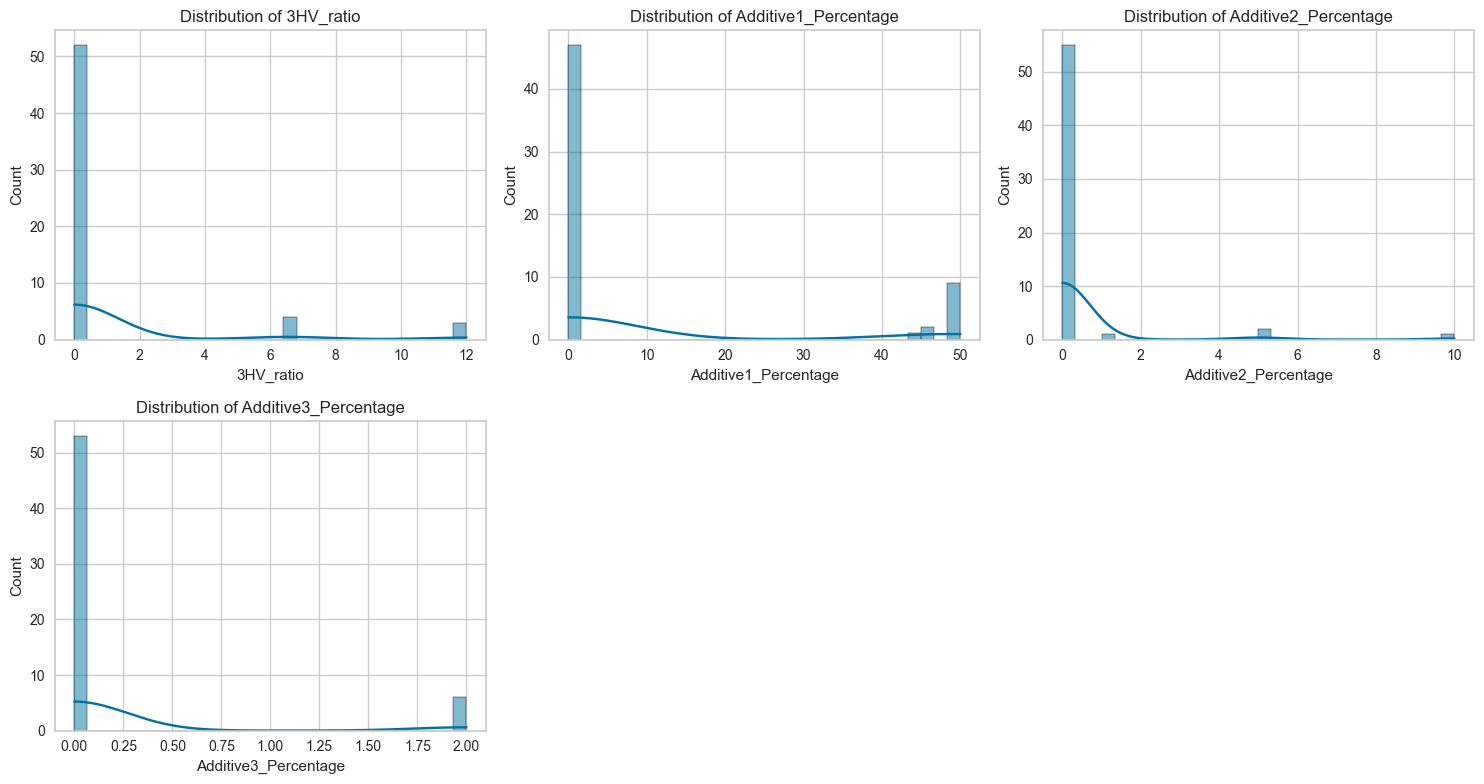

In [14]:
# Plot the distribution of numerical features
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(X_train[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Outlier Detection

In [15]:
# No outlier detection due to data shortage
X_train_clean = X_train.copy()
y_train_clean = y_train.copy()

## Examine Categorical Features

In [16]:
for column in X_train_clean.select_dtypes(include=['object']).columns.tolist():
    print("\n")
    print(X_train[column].value_counts())



Additive1_Use
not_applicable    47
Plasticizer        6
Structural         3
Flexibilizer       3
Name: count, dtype: int64


Additive2_Use
not_applicable         53
Natural_Antioxidant     6
Name: count, dtype: int64


Additive3_Use
not_applicable    53
Chain_Extender     6
Name: count, dtype: int64


Species_Group
Aquatic_Organisms    36
Terrestrial_Plant    23
Name: count, dtype: int64


Exposure_type
Waterborne    32
Soil          23
Orally         4
Name: count, dtype: int64


Media_type
Sandy_Soil                                10
Filtered_Seawater                          7
Disinfected_Seawater                       5
Agricultural_soil                          4
Standard_soil_with_5_compost               4
Artificial_Freshwater                      4
Diluted_biodegraded_synthetic_seawater     4
Egg_water                                  4
Diluted_biodegraded_natural_seawater       3
Artificial_Seawater                        3
Standard_soil_with_10_compost              3
Stein

## Handle Categorical Features

In [17]:
# Group Media type in smaller meaningfull categories
media_merge_map = {
    # Freshwater
    'Artificial_Freshwater': 'Freshwater',
    'Freshwater_simulation': 'Freshwater',
    'Freshwater':            'Freshwater',

    # Seawater
    'Filtered_Seawater':                       'Seawater',
    'Disinfected_Seawater':                    'Seawater',
    'Artificial_Seawater':                     'Seawater',
    'Autoclaved_Seawater':                     'Seawater',
    'Diluted_biodegraded_natural_seawater':    'Seawater',
    'Diluted_biodegraded_synthetic_seawater':  'Seawater',

    # Soil
    'Sandy_Soil':                    'Soil',
    'Agricultural_soil':             'Soil',
    'Standard_soil_with_5_compost':  'Soil',
    'Standard_soil_with_10_compost': 'Soil',
    'Potting_Substrate':             'Soil',

    # Other
    'Egg_water':        'Other',
    'Steinberg_medium': 'Other',
}

X_train_clean['Media_type'] = X_train_clean['Media_type'].map(media_merge_map)
X_test['Media_type'] = X_test['Media_type'].map(media_merge_map)
print(X_train_clean['Media_type'].value_counts(normalize=True))
print(X_test['Media_type'].value_counts(normalize=True))

Media_type
Seawater      0.389831
Soil          0.389831
Freshwater    0.118644
Other         0.101695
Name: proportion, dtype: float64
Media_type
Soil          0.357143
Freshwater    0.285714
Seawater      0.214286
Other         0.142857
Name: proportion, dtype: float64


In [18]:
def fit_rare_category_collapser(X, cat_cols, min_freq=0.05, other_label='other'):
    """
    Learns which categories are rare from training data only.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_freq : float
        Minimum proportion to keep a category.
    other_label : str

    Returns
    -------
    rare_map : dict mapping column -> set of rare categories
    """
    rare_map = {}
    for col in cat_cols:
        freq = X[col].value_counts(normalize=True)
        rare_map[col] = set(freq[freq < min_freq].index)
    return rare_map


def transform_rare_categories(X, rare_map, other_label='other'):
    """
    Applies rare category collapsing learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    rare_map : dict from fit_rare_category_collapser
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, rare_cats in rare_map.items():
        X[col] = X[col].replace(rare_cats, other_label)
    return X


def fit_merge_small_other(X, cat_cols, min_count=5, other_label='other'):
    """
    Learns from training data which columns have a small 'other' group
    and which named category to merge it into.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_count : int
        Minimum absolute count for 'other' to be kept as its own category.
    other_label : str

    Returns
    -------
    merge_map : dict mapping column -> target category to absorb 'other'
                (None if 'other' is large enough or doesn't exist)
    """
    merge_map = {}
    for col in cat_cols:
        if other_label not in X[col].values:
            merge_map[col] = None
            continue
        other_count = (X[col] == other_label).sum()
        if other_count < min_count:
            freq = X[col][X[col] != other_label].value_counts()
            least_frequent = freq.index[-1]
            print(f"[{col}] 'other' has only {other_count} rows → merging into '{least_frequent}'")
            merge_map[col] = least_frequent
        else:
            merge_map[col] = None
    return merge_map


def transform_merge_small_other(X, merge_map, other_label='other'):
    """
    Applies the merging of small 'other' groups learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    merge_map : dict from fit_merge_small_other
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, target_cat in merge_map.items():
        if target_cat is not None:
            X[col] = X[col].replace(other_label, target_cat)
    return X


# ── Pipeline ──────────────────────────────────────────────────────────────────

cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Step 1: collapse rare categories into 'other' (fit on train only)
rare_map = fit_rare_category_collapser(X_train_clean, cat_cols, min_freq=0.05)
X_train_clean = transform_rare_categories(X_train_clean, rare_map)
X_test_clean = transform_rare_categories(X_test, rare_map)

# Step 2: merge small 'other' groups into least frequent named category (fit on train only)
merge_map = fit_merge_small_other(X_train_clean, cat_cols, min_count=5)
X_train_clean = transform_merge_small_other(X_train_clean, merge_map)
X_test_clean = transform_merge_small_other(X_test_clean, merge_map)

In [19]:
# Check the new categories
for col in cat_cols:
    print("\n")
    print(X_train_clean[col].value_counts())



Additive1_Use
not_applicable    47
Plasticizer        6
Structural         3
Flexibilizer       3
Name: count, dtype: int64


Additive2_Use
not_applicable         53
Natural_Antioxidant     6
Name: count, dtype: int64


Additive3_Use
not_applicable    53
Chain_Extender     6
Name: count, dtype: int64


Species_Group
Aquatic_Organisms    36
Terrestrial_Plant    23
Name: count, dtype: int64


Exposure_type
Waterborne    32
Soil          23
Orally         4
Name: count, dtype: int64


Media_type
Seawater      23
Soil          23
Freshwater     7
Other          6
Name: count, dtype: int64


Toxicity
Acute      34
Chronic    25
Name: count, dtype: int64


In [20]:
y_train_clean = y_train_clean.loc[X_train_clean.index].reset_index(drop=True)
y_test_clean  = y_test.loc[X_test_clean.index].reset_index(drop=True)

X_train_clean = X_train_clean.reset_index(drop=True)
X_test_clean  = X_test_clean.reset_index(drop=True)

assert len(X_train_clean) == len(y_train_clean)
assert len(X_test_clean)  == len(y_test_clean)
print(f"Train: {len(X_train_clean)} rows | Test: {len(X_test_clean)} rows")

Train: 59 rows | Test: 14 rows


# Feature Selection 

In [21]:
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (4):
  - 3HV_ratio
  - Additive1_Percentage
  - Additive2_Percentage
  - Additive3_Percentage

Categorical features (7):
  - Additive1_Use
  - Additive2_Use
  - Additive3_Use
  - Species_Group
  - Exposure_type
  - Media_type
  - Toxicity


## Mutual Information 

In [22]:
# Check mutual information between features and target  (numerical and categorical features(ordinal encoded))
# Ordinal encode categorical features for mutual information calculation
ordinal_encoder = OrdinalEncoder()
X_train_encoded = X_train_clean.copy()
X_train_encoded[categorical_cols] = ordinal_encoder.fit_transform(X_train_encoded[categorical_cols])    
mi_scores = mutual_info_classif(X_train_encoded, y_train_clean, discrete_features=[X_train_encoded.columns.get_loc(c) for c in categorical_cols], random_state=10)
mi_scores_series = pd.Series(mi_scores, index=X_train_encoded.columns).sort_values(ascending=False)
print("Mutual Information Scores:")
print(mi_scores_series)

Mutual Information Scores:
Additive1_Use           0.171709
Media_type              0.166538
Additive1_Percentage    0.158804
Additive3_Percentage    0.131258
Exposure_type           0.113909
Species_Group           0.113335
3HV_ratio               0.080598
Additive2_Use           0.078204
Additive3_Use           0.078204
Toxicity                0.006912
Additive2_Percentage    0.000000
dtype: float64


In [23]:
# encoder = OrdinalEncoder(
#     handle_unknown="use_encoded_value",
#     unknown_value=-1
# )
# X_train_encoded = X_train_clean.copy()
# X_train_encoded[categorical_cols] = encoder.fit_transform(
#     X_train_clean[categorical_cols]
# )

In [24]:
# discrete_mask = [col in categorical_cols for col in X_train_encoded.columns]

# mi_scores = mutual_info_classif(
#     X_train_encoded, y_train_clean,
#     discrete_features=discrete_mask,
#     random_state=42
# )
# mi_df = pd.DataFrame({
#     "feature"  : X_train_encoded.columns,
#     "mi_score" : mi_scores
# }).sort_values("mi_score", ascending=False).reset_index(drop=True)

# print("=== Mutual Information (vs target) ===")
# print(mi_df.to_string(index=False))

## Spearman (Num vs Num)

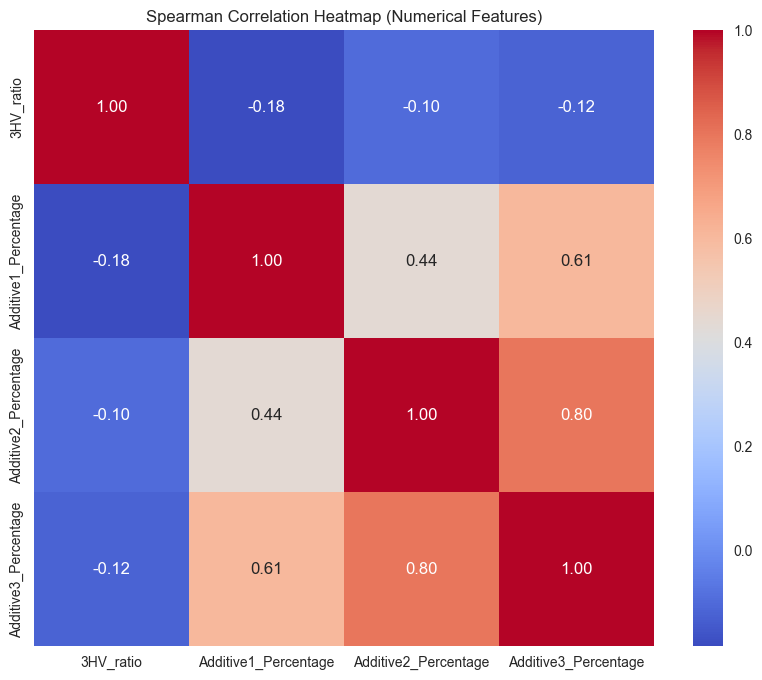

In [25]:
# Use Spearman correlation for numerical features between them
spearman_corr = X_train_clean[numerical_cols].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Correlation Heatmap (Numerical Features)')
plt.show()

In [26]:
# spearman_matrix = (
#     X_train_clean[numerical_cols]
#     .corr(method="kendall") # or spearman for non normally distributed variables
#     .abs()
# )
# print("=== Spearman Correlation (numerical vs numerical) ===")
# spearman_matrix.round(2)

## Cramér's V (Cat vs Cat)

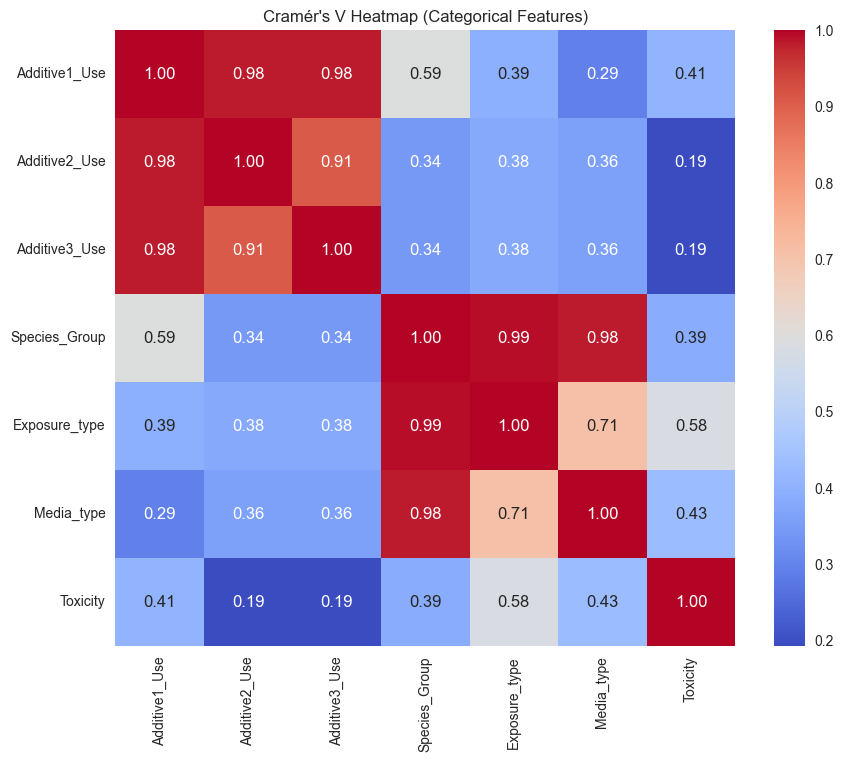

In [27]:
# Use cramer's V for categorical features between them
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))    
cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cramers_v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train_clean[col1], X_train_clean[col2])
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramér's V Heatmap (Categorical Features)")
plt.show()

In [28]:
# def cramers_v(col_a, col_b):
#     contingency = pd.crosstab(col_a, col_b)
#     chi2, _, _, _ = chi2_contingency(contingency)
#     n = contingency.values.sum()
#     r, k = contingency.shape
#     denom = n * (min(r, k) - 1)
#     return np.sqrt(chi2 / denom) if denom > 0 else 0.0

# cat_cols = categorical_cols
# cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

# for col_a in cat_cols:
#     for col_b in cat_cols:
#         if col_a == col_b:
#             cramers_matrix.loc[col_a, col_b] = 1.0  # skip computation, always 1
#         else:
#             cramers_matrix.loc[col_a, col_b] = cramers_v(
#                 X_train_clean[col_a], X_train_clean[col_b]
#             )

# print("=== Cramér's V (categorical vs categorical) ===")
# cramers_matrix.round(2)

## Drop Unnecessary Features

In [29]:
# mi_threshold = 0.05  # adjust as needed
# features_to_keep = mi_df[mi_df['mi_score'] >= mi_threshold]['feature'].tolist()

# X_train_clean = X_train_clean[features_to_keep]
# X_test_clean  = X_test_clean[features_to_keep]

# Machine Learning Algorithm

In [30]:
# Recompute numerical and categorical features 
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (4):
  - 3HV_ratio
  - Additive1_Percentage
  - Additive2_Percentage
  - Additive3_Percentage

Categorical features (7):
  - Additive1_Use
  - Additive2_Use
  - Additive3_Use
  - Species_Group
  - Exposure_type
  - Media_type
  - Toxicity


In [31]:
features_num = numerical_cols
features_cat = categorical_cols 

In [32]:
# Preprocessing pipeline
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary"), features_cat),
    ],
    remainder="drop",
)

# Fit the preprocessor on the training data and transform both train and test sets
X_train_preprocessed = pre.fit_transform(X_train_clean)
X_test_preprocessed  = pre.transform(X_test_clean)

# Label encode the target variable for PyCaret and convert to DataFrame for easier handling ('Non_Toxic' -> 0, 'Toxic' -> 1)
label_encoder = LabelEncoder()
# y_train_clean = label_encoder.fit_transform(y_train_clean)
# y_test_clean  = label_encoder.transform(y_test_clean)
y_train_clean = pd.Series(label_encoder.fit_transform(y_train_clean), index=X_train_clean.index)
y_test_clean  = pd.Series(label_encoder.transform(y_test_clean), index=X_test_clean.index)    


# Get feature names after one-hot encoding
ohe_feature_names = pre.named_transformers_["cat"].get_feature_names_out(features_cat)
feature_names = features_num + list(ohe_feature_names)
print(f"Total features after preprocessing: {len(feature_names)}")

# Convert back to DataFrame for easier handling
X_train_df = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed, columns=feature_names) 

# Join the target back to the preprocessed features for PyCaret
train_data = X_train_df.copy()
train_data[target] = y_train_clean.values

test_data = X_test_df.copy()
test_data[target] = y_test_clean.values


Total features after preprocessing: 19


In [33]:
y_train_clean.value_counts()

1    30
0    29
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import pandas as pd

# ── DEFINE MODELS ─────────────────────────────────────────────────────────────
models = {
    'Random Forest':  RandomForestClassifier(class_weight='balanced_subsample', random_state=42),
    'Extra Trees':    ExtraTreesClassifier(class_weight='balanced', random_state=42),
    'GBC':            GradientBoostingClassifier(random_state=42),
    'CatBoost':       CatBoostClassifier(verbose=0, random_state=42),
    'LightGBM':       LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    'XGBoost':        XGBClassifier(random_state=42, eval_metric='logloss'),
    'Logistic Reg':   LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'SVM':            SVC(class_weight='balanced', probability=True, random_state=42),
}

# ── CV STRATEGY ───────────────────────────────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)

# ── SCORING ───────────────────────────────────────────────────────────────────
scoring = {
    'AUC':      'roc_auc',
    'F1_macro': 'f1_macro',
    'MCC':      'matthews_corrcoef',
    'Recall':   'recall_macro'
}

# ── RUN COMPARISON ────────────────────────────────────────────────────────────
results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train_df,       # your preprocessed train features
        y_train_clean,          # your train labels
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    results.append({
        'Model': name,
        'AUC':      f"{scores['test_AUC'].mean():.4f} ± {scores['test_AUC'].std():.4f}",
        'F1_macro': f"{scores['test_F1_macro'].mean():.4f} ± {scores['test_F1_macro'].std():.4f}",
        'MCC':      f"{scores['test_MCC'].mean():.4f} ± {scores['test_MCC'].std():.4f}",
        'Recall':   f"{scores['test_Recall'].mean():.4f} ± {scores['test_Recall'].std():.4f}",
    })
    print(f"✓ {name} done")

# ── SHOW RESULTS ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.sort_values('AUC', ascending=False))

✓ Random Forest done
✓ Extra Trees done
✓ GBC done
✓ CatBoost done
✓ LightGBM done
✓ XGBoost done
✓ Logistic Reg done
✓ SVM done
                           AUC         F1_macro              MCC  \
Model                                                              
Random Forest  0.7693 ± 0.1277  0.6248 ± 0.1153  0.3136 ± 0.2372   
CatBoost       0.7686 ± 0.1291  0.6680 ± 0.0994  0.3968 ± 0.1917   
XGBoost        0.7683 ± 0.1291  0.6387 ± 0.1202  0.3282 ± 0.2319   
Extra Trees    0.7555 ± 0.1270  0.6180 ± 0.1171  0.2906 ± 0.2407   
GBC            0.7547 ± 0.1399  0.6433 ± 0.1226  0.3495 ± 0.2440   
Logistic Reg   0.7447 ± 0.1404  0.6440 ± 0.1176  0.3464 ± 0.2179   
SVM            0.6981 ± 0.1541  0.6332 ± 0.1121  0.3350 ± 0.2139   
LightGBM       0.6724 ± 0.1393  0.6619 ± 0.1405  0.3755 ± 0.2547   

                        Recall  
Model                           
Random Forest  0.6407 ± 0.1097  
CatBoost       0.6815 ± 0.0919  
XGBoost        0.6527 ± 0.1114  
Extra Trees    0.6320 ± 0

: 

In [ ]:
# Pycaret setup
clf = setup(data=train_data,
            test_data=test_data,
            target='Toxicity_Classification',
            preprocess=False,          # data already preprocessed
            fix_imbalance=True,
            # fold=5,
            fold_strategy=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42),
            index=False,
            session_id=42)

# Compare models and select the best one based on AUC
best_model = compare_models(sort='auc', n_select=1)
print(f"Best model: {best_model}")



,Description,Value
0,Session id,42
1,Target,Toxicity_Classification
2,Target type,Binary
3,Original data shape,"(73, 20)"
4,Transformed data shape,"(73, 20)"
5,Transformed train set shape,"(59, 20)"
6,Transformed test set shape,"(14, 20)"
7,Numeric features,19


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,14:26:14
Status,. . . . . . . . . . . . . . . . . .,Compiling Final Models
Estimator,. . . . . . . . . . . . . . . . . .,Extreme Gradient Boosting


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.6620,0.7692,0.7267,0.6638,0.6794,0.3234,0.3457,0.0018
catboost,CatBoost Classifier,0.6791,0.7677,0.7967,0.6663,0.7143,0.3562,0.3851,0.0514
rf,Random Forest Classifier,0.6505,0.7638,0.7467,0.6452,0.6761,0.2981,0.3289,0.0120
et,Extra Trees Classifier,0.6312,0.7595,0.6467,0.6556,0.6305,0.2630,0.2845,0.0096
gbc,Gradient Boosting Classifier,0.6706,0.7575,0.7700,0.6636,0.6994,0.3399,0.3673,0.0034
dt,Decision Tree Classifier,0.6261,0.7528,0.6467,0.6460,0.6263,0.2526,0.2735,0.0010
lr,Logistic Regression,0.6550,0.7288,0.7867,0.6422,0.6967,0.3070,0.3348,0.0132
knn,K Neighbors Classifier,0.6186,0.7271,0.7600,0.6051,0.6601,0.2329,0.2709,0.0014
ridge,Ridge Classifier,0.6215,0.7202,0.7367,0.6140,0.6570,0.2403,0.2676,0.0010
ada,Ada Boost Classifier,0.6009,0.7185,0.7000,0.5971,0.6328,0.2001,0.2232,0.0036


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

In [ ]:
# Optimize the best model's hyperparameters using Optuna with early stopping
tuned_model = tune_model(best_model,
                         optimize='auc',
                         search_library='optuna',
                         n_iter=50,
                         )

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,14:22:53
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,Random Forest Classifier


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

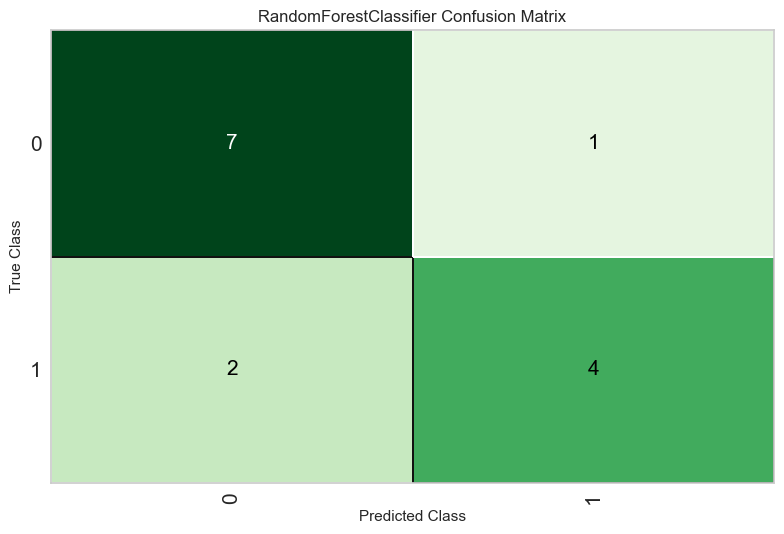

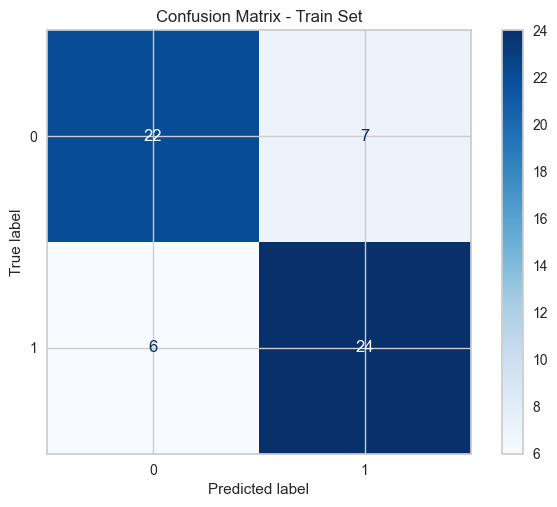

In [ ]:
# ── CONFUSION MATRIX ON TEST SET ─────────────────────────────────────────────
plot_model(tuned_model, plot='confusion_matrix')

# ── CONFUSION MATRIX ON TRAIN SET (manual) ───────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get train predictions
X_train_pred = tuned_model.predict(X_train_df)

# Plot
cm = confusion_matrix(y_train_clean, X_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Train Set')
plt.show()

In [ ]:
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary"), features_cat),
    ],
    remainder="drop",
)


clf = Pipeline([
    ("pre", pre),
    ("rf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced_subsample"
    )
    )
])

Fitting 5 folds for each of 504 candidates, totalling 2520 fits
Best params: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10, 'rf__n_estimators': 20}
Best CV score: 0.7284 ± 0.0617


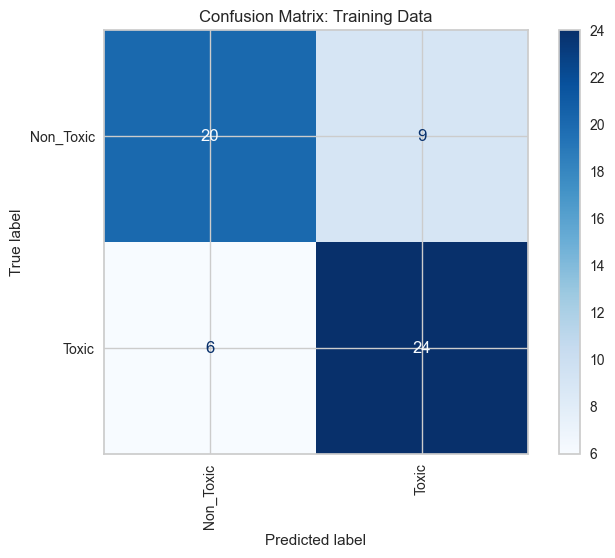

In [ ]:
param_grid = {
    "rf__n_estimators": [20, 40, 50, 100, 200, 400, 500],
    "rf__max_depth": [None, 10, 20, 40],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(
    n_splits=5, 
    shuffle=True,
    random_state=42
)


grid = GridSearchCV(
    clf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1 # or 2 to check more information 
)

grid.fit(X_train_clean, y_train_clean)
best_clf = grid.best_estimator_ 

std_cv = grid.cv_results_["std_test_score"][grid.best_index_]

cmd = ConfusionMatrixDisplay.from_estimator(
    best_clf, 
    X_train_clean, 
    y_train_clean, 
    display_labels=best_clf.classes_, 
    cmap=plt.cm.Blues,                
    xticks_rotation='vertical'        
)



print("Best params:", grid.best_params_)
print(f"Best CV score: {grid.best_score_:.4f} ± {std_cv:.4f}")

plt.title("Confusion Matrix: Training Data")
# plt.savefig('Confusion_Matrix_Train.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
for col in features_cat:
    train_cats = set(X_train_clean[col].unique())
    test_cats  = set(X_test_clean[col].unique())
    
    unseen = test_cats - train_cats
    
    if unseen:
        print(f"[{col}] Dropping {len(unseen)} unseen categories: {unseen}")
        X_test_clean = X_test_clean[~X_test_clean[col].isin(unseen)]

# realign y_test after row drops
y_test_clean   = y_test_clean.loc[X_test_clean.index].reset_index(drop=True)
X_test_clean = X_test_clean.reset_index(drop=True)

print(f"\nX_test rows remaining: {len(X_test_clean)}")
assert len(X_test_clean) == len(y_test_clean)

[Additive1_Use] Dropping 1 unseen categories: {'Polymer_Matrix'}

X_test rows remaining: 12



=== Test metrics ===
Accuracy: 0.8333333333333334
Balanced Accuracy: 0.875
Matthews CorrCoef: 0.7071067811865476
Macro F1: 0.8285714285714285
Precision (per class): [1.         0.66666667]
Recall (per class): [0.75 1.  ]
F1 (per class): [0.85714286 0.8       ]
Jaccard (per class): [0.75       0.66666667]
Confusion Matrix:
 [[6 2]
 [0 4]]


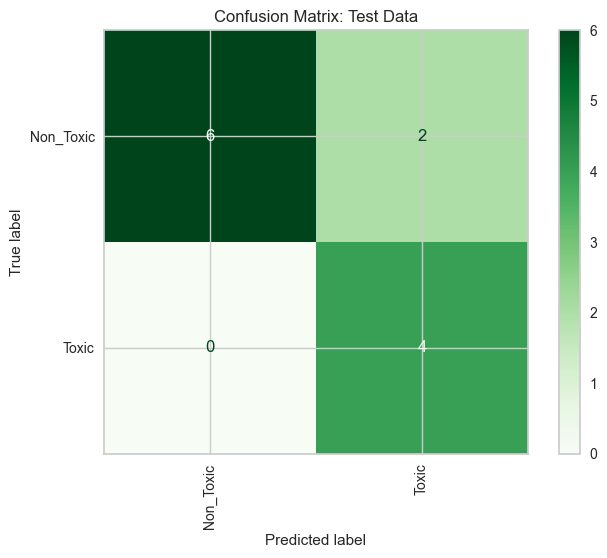

In [ ]:
y_pred = best_clf.predict(X_test_clean)

print("\n=== Test metrics ===")

# Overall metrics
print("Accuracy:", accuracy_score(y_test_clean, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_clean, y_pred))
print("Matthews CorrCoef:", matthews_corrcoef(y_test_clean, y_pred)) # correlation between true labels and predicted ones
print("Macro F1:", f1_score(y_test_clean, y_pred, average="macro"))

# Per-class metrics
print("Precision (per class):", precision_score(y_test_clean, y_pred, average=None))
print("Recall (per class):", recall_score(y_test_clean, y_pred, average=None))
print("F1 (per class):", f1_score(y_test_clean, y_pred, average=None))
print("Jaccard (per class):", jaccard_score(y_test_clean, y_pred, average=None))

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test_clean, y_pred))

cmd = ConfusionMatrixDisplay.from_estimator(
    best_clf, 
    X_test_clean, 
    y_test_clean, 
    display_labels=best_clf.classes_, 
    cmap=plt.cm.Greens,                
    xticks_rotation='vertical'        
)

plt.title("Confusion Matrix: Test Data")
plt.savefig('Confusion_Matrix_Test.png', dpi=600, bbox_inches='tight')
plt.show()

# Jacpotpy

In [ ]:
df_train = X_train_clean.copy()
df_train[target] = y_train_clean

train_dataset = JaqpotTabularDataset(
    df=df_train,
    x_cols=X_train_clean.columns.to_list(),
    y_cols=target,
    task="BINARY_CLASSIFICATION",
)

In [ ]:
df_test = X_test_clean.copy()
df_test[target] = y_test_clean

test_dataset = JaqpotTabularDataset(
    df=df_test,
    x_cols=X_test_clean.columns.to_list(),
    y_cols=target,
    task="BINARY_CLASSIFICATION",
)

In [ ]:
preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_features', StandardScaler(), features_num),
        ('categorical_features', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), features_cat),
    ],
    remainder='drop',
)

In [ ]:
best_params = {k.replace("rf__", ""): v for k, v in grid.best_params_.items()}

model = RandomForestClassifier(
                            random_state=42,
                            **best_params
                            )

jaqpot_model = SklearnModel(
    dataset=train_dataset,
    model=model,
    doa=[Leverage(), BoundingBox(), MeanVar()],
    preprocess_x=preprocessing)
jaqpot_model.random_seed = 1231
jaqpot_model.fit()

Goodness-of-fit metrics on training set:
{'accuracy': 0.7457627118644068, 'balancedAccuracy': 0.7448275862068966, 'precision': array([0.68965517, 0.8       ]), 'recall': array([0.76923077, 0.72727273]), 'f1Score': array([0.72727273, 0.76190476]), 'jaccard': array([0.57142857, 0.61538462]), 'matthewsCorrCoef': 0.4930674448637536, 'confusionMatrix': array([[20,  9],
       [ 6, 24]])}


In [ ]:
# Perform cross-validation on the training data
jaqpot_model.cross_validate(train_dataset, n_splits=5)

{'accuracy': 0.6469696969696971,
 'balancedAccuracy': 0.6875396825396826,
 'precision': array([0.72666667, 0.6484127 ]),
 'recall': array([0.64833333, 0.68666667]),
 'f1Score': array([0.64502165, 0.62692308]),
 'jaccard': array([0.49383117, 0.48944444]),
 'matthewsCorrCoef': 0.3542965316800215,
 'confusionMatrix': array([[3.8, 2. ],
        [2.2, 3.8]])}

In [ ]:
# Evaluate the model on the test dataset
jaqpot_model.evaluate(test_dataset)

{'accuracy': 0.8333333333333334,
 'balancedAccuracy': 0.875,
 'precision': array([0.75, 1.  ]),
 'recall': array([1.        , 0.66666667]),
 'f1Score': array([0.85714286, 0.8       ]),
 'jaccard': array([0.75      , 0.66666667]),
 'matthewsCorrCoef': 0.7071067811865476,
 'confusionMatrix': array([[6, 2],
        [0, 4]])}

In [ ]:
# # Conducts a randomization test to assess the model's robustness
# jaqpot_model.randomization_test(
#     train_dataset=train_dataset,
#     test_dataset=test_dataset,
#     n_iters=10,
# )

In [ ]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)

In [ ]:
summary = {}
for key in ['LEVERAGE','BOUNDING_BOX','MEAN_VAR']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary


{'LEVERAGE': {'n_total': 12, 'n_in': 12, 'n_out': 0},
 'BOUNDING_BOX': {'n_total': 12, 'n_in': 12, 'n_out': 0},
 'MEAN_VAR': {'n_total': 12, 'n_in': 4, 'n_out': 8}}

In [ ]:
# # Upload the pretrained model on Jaqpot
# jaqpot = Jaqpot()
# jaqpot.login()
# jaqpot_model.deploy_on_jaqpot(
#     jaqpot=jaqpot,
#     name="Cytotoxicity_model_A.N.I.P.H.",
#     description="Predict cytotoxicity of PHBV polymers.",
#     visibility="PUBLIC",
# )

# SHAP diagrams

In [ ]:
preprocessor = best_clf.named_steps["pre"]
rf_model     = best_clf.named_steps["rf"]

X_train_transformed = preprocessor.transform(X_train_clean)

ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(features_cat)
feature_names = list(features_num) + list(cat_feature_names)

In [ ]:
explainer = shap.TreeExplainer(rf_model, model_output="raw")
shap_values_all = explainer.shap_values(X_train_transformed)

In [ ]:
sv = shap_values_all[:, :, 1]  # (n_samples, n_features, n_classes)

print("SHAP for class 1:", sv.shape) 
print("X_test_transformed:", X_train_transformed.shape)


SHAP for class 1: (59, 19)
X_test_transformed: (59, 19)


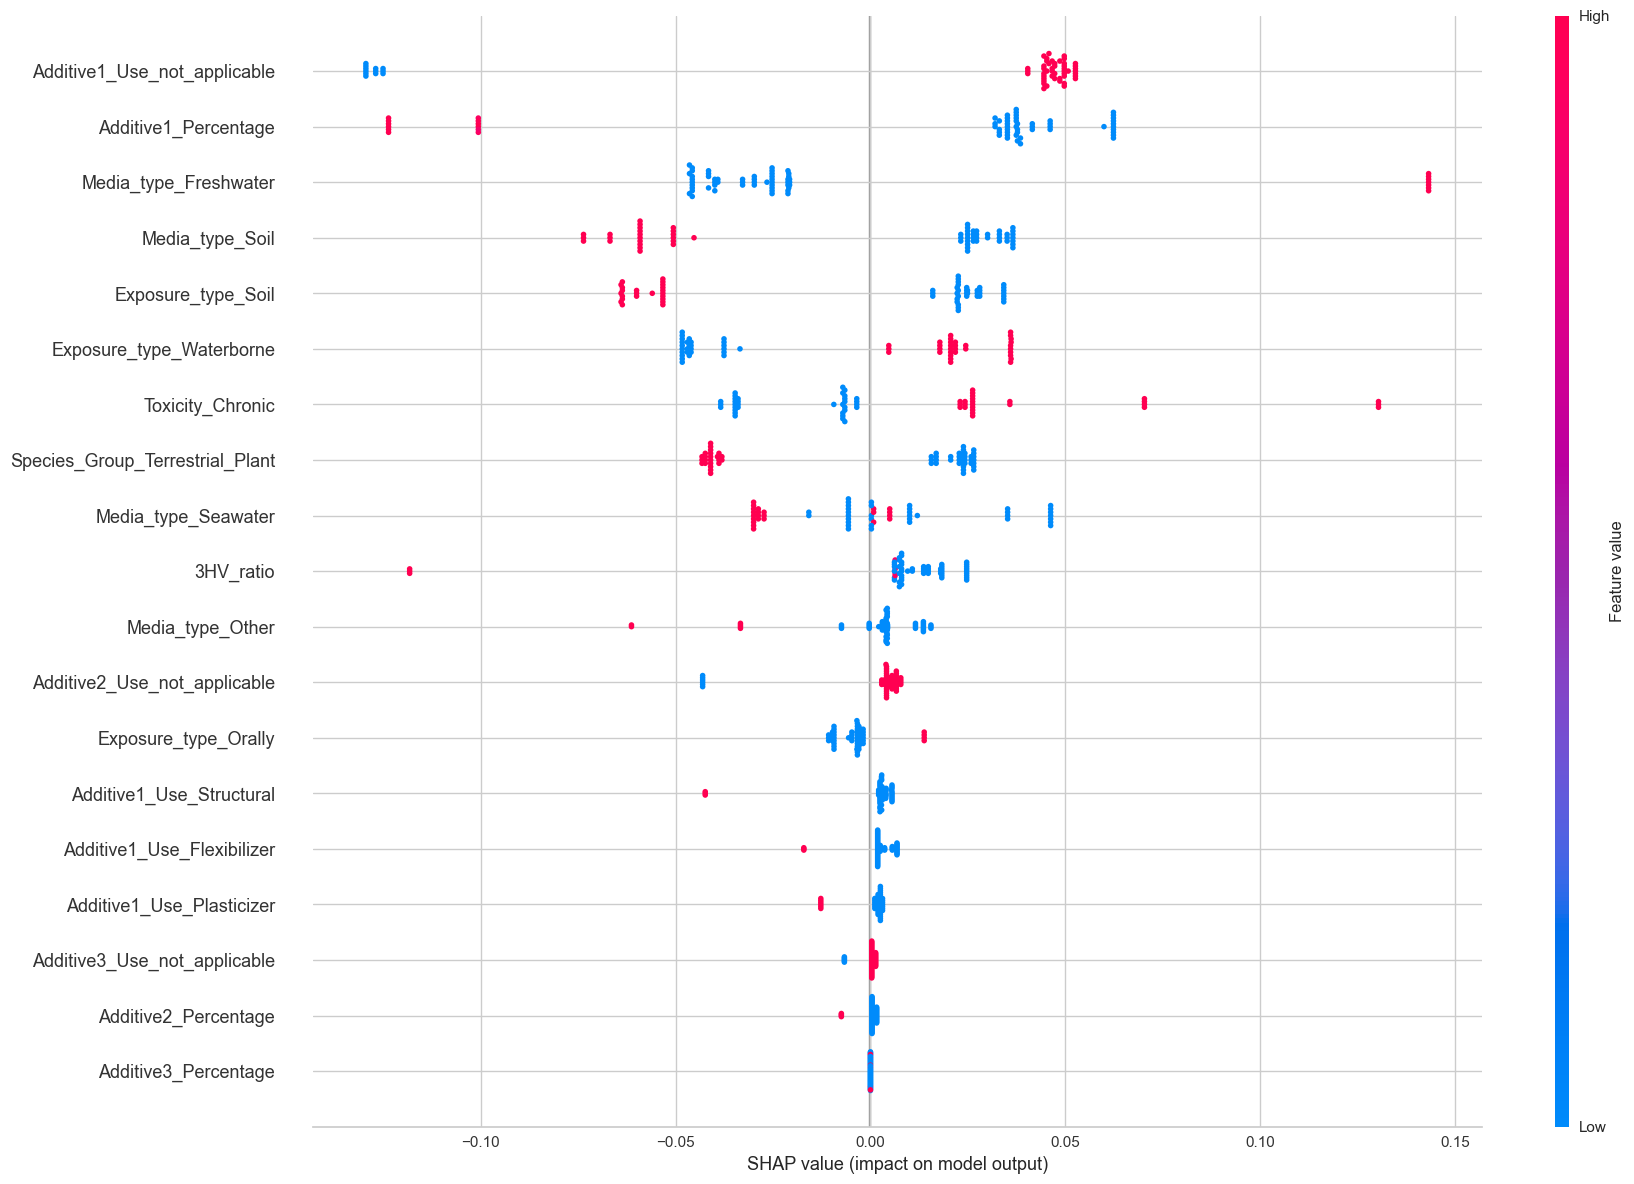

In [ ]:
shap.summary_plot(
    sv,
    X_train_transformed,
    feature_names=feature_names,
    max_display=len(feature_names), 
    plot_size=(18, 12),
    show=False
)

# plt.savefig("shap_summary_cytotoxicity.png", dpi=600, bbox_inches="tight")
# plt.close()
plt.show()

In [ ]:
shap_df = pd.DataFrame(sv, columns=feature_names)

# Map each encoded column back to its original feature
original_feature = {}
for col in feature_names:
    for cat_col in categorical_cols:
        if col.startswith(cat_col + '_') or col == cat_col:
            original_feature[col] = cat_col
            break
    else:
        original_feature[col] = col  # numerical cols keep their name

# Sum absolute SHAP values per original feature
shap_grouped = (
    shap_df.rename(columns=original_feature)
    .abs()
    .T.groupby(level=0).sum().T
)

mean_shap = shap_grouped.abs().mean().sort_values(ascending=False)
mean_shap_df = mean_shap.reset_index()
mean_shap_df.columns = ['Feature', 'Mean |SHAP|']
mean_shap_df = mean_shap_df.sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
mean_shap_df.index += 1  # start ranking from 1 instead of 0
print(mean_shap_df)

# Export to Excel
# mean_shap_df.to_excel('shap_feature_importance.xlsx', index=True)


                 Feature  Mean |SHAP|
1             Media_type     0.115914
2          Exposure_type     0.077470
3          Additive1_Use     0.076488
4   Additive1_Percentage     0.057159
5               Toxicity     0.030912
6          Species_Group     0.029879
7              3HV_ratio     0.018488
8          Additive2_Use     0.008997
9          Additive3_Use     0.001218
10  Additive2_Percentage     0.001211
11  Additive3_Percentage     0.000000
